# Delhivery Graph ETA Optimization

In [1]:
!pip install -q pandas numpy networkx scikit-learn lightgbm matplotlib seaborn plotly


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Data Pipeline

In [2]:
import pandas as pd
import numpy as np
import os

data_path = 'delivery_data.csv'
if not os.path.exists(data_path) and os.path.exists('../data/raw/delivery_data.csv'):
    data_path = '../data/raw/delivery_data.csv'

def clean_data(path):
    df = pd.read_csv(path)
    df['source_name'] = df['source_name'].fillna('Unknown')
    df['destination_name'] = df['destination_name'].fillna('Unknown')
    
    df = df[df['segment_actual_time'] >= 0]
    df.loc[df['segment_osrm_time'] == 0, 'segment_osrm_time'] = 1.0
    df['delay_ratio'] = df['segment_actual_time'] / df['segment_osrm_time']
    
    df['hour'] = pd.to_datetime(df['trip_creation_time']).dt.hour
    
    def get_tod(h):
        if 5 <= h < 12: return 'Morning'
        elif 12 <= h < 17: return 'Afternoon'
        elif 17 <= h < 22: return 'Evening'
        else: return 'Night'
    
    df['time_of_day'] = df['hour'].apply(get_tod)
    return df

try:
    trips = clean_data(data_path)

    group_cols = ['source_center', 'destination_center', 'route_type', 'time_of_day']
    edges = trips.groupby(group_cols).agg(
        delay_ratio=('delay_ratio', 'median'),
        actual_time=('segment_actual_time', 'median'),
        osrm_time=('segment_osrm_time', 'median'),
        distance=('segment_osrm_distance', 'median'),
        trip_count=('trip_uuid', 'count')
    ).reset_index()

    src_names = trips[['source_center', 'source_name']].drop_duplicates('source_center').set_index('source_center')['source_name']
    dst_names = trips[['destination_center', 'destination_name']].drop_duplicates('destination_center').set_index('destination_center')['destination_name']
    
    edges['src_name'] = edges['source_center'].map(src_names)
    edges['dst_name'] = edges['destination_center'].map(dst_names)

    nodes_src = trips[['source_center', 'source_name']].rename(columns={'source_center': 'node_id', 'source_name': 'name'})
    nodes_dst = trips[['destination_center', 'destination_name']].rename(columns={'destination_center': 'node_id', 'destination_name': 'name'})
    nodes = pd.concat([nodes_src, nodes_dst]).drop_duplicates('node_id')

    print(f"Edges: {edges.shape[0]}, Nodes: {nodes.shape[0]}")
except FileNotFoundError:
    print(f"File {data_path} not found.")


Edges: 4118, Nodes: 1657


### 2. Network Analysis

,name,risk_score,delayed_trips
32,Gurgaon_Bilaspur_HB (Haryana),4937.284499,22419.0
4,Bangalore_Nelmngla_H (Karnataka),1229.062701,9837.0
2,Bhiwandi_Mankoli_HB (Maharashtra),632.545277,9085.0
111,Hyderabad_Shamshbd_H (Telangana),309.389747,3340.0
94,Kolkata_Dankuni_HB (West Bengal),236.802464,2612.0


C:\tmp\ipykernel_25168\1996390230.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hubs.head(5), x='risk_score', y='name', palette='Reds_r')


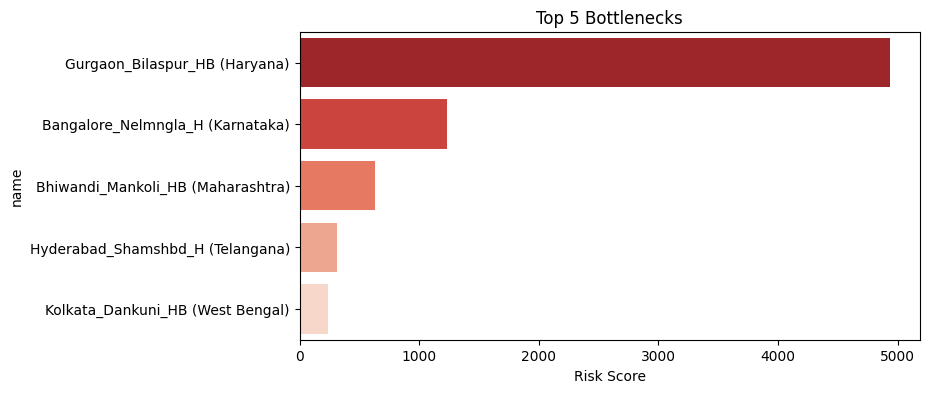

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

if 'nodes' in locals():
    G = nx.DiGraph()
    for _, r in nodes.iterrows(): G.add_node(r['node_id'], name=r['name'])
    for _, r in edges.iterrows(): G.add_edge(r['source_center'], r['destination_center'], weight=r['delay_ratio'], count=r['trip_count'])

    metrics = pd.DataFrame({
        'node_id': list(G.nodes()),
        'betweenness': list(nx.betweenness_centrality(G, weight=None).values()),
        'in_deg': list(dict(G.in_degree()).values()),
        'out_deg': list(dict(G.out_degree()).values()),
        'clustering': list(nx.clustering(G).values())
    })

    bad_edges = edges[edges['delay_ratio'] > 1.20].copy()
    delays = bad_edges.groupby('source_center').agg(delayed_trips=('trip_count', 'sum')).reset_index().rename(columns={'source_center': 'node_id'})

    hub_stats = metrics.merge(delays, on='node_id', how='left').fillna(0).merge(nodes, on='node_id', how='left')
    hub_stats['risk_score'] = hub_stats['betweenness'] * hub_stats['delayed_trips']
    
    top_hubs = hub_stats.sort_values('risk_score', ascending=False)
    display(top_hubs[['name', 'risk_score', 'delayed_trips']].head(5))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=top_hubs.head(5), x='risk_score', y='name', palette='Reds_r')
    plt.title('Top 5 Bottlenecks')
    plt.xlabel('Risk Score')
    plt.show()

### 3. Graph-Enhanced ETA Prediction

In [4]:
from sklearn.manifold import SpectralEmbedding
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

if 'G' in locals():
    adj = nx.to_scipy_sparse_array(G, nodelist=list(G.nodes()), weight='weight')
    sym_adj = adj.maximum(adj.transpose()).tocsr()
    sym_adj.indices, sym_adj.indptr = sym_adj.indices.astype(np.int32), sym_adj.indptr.astype(np.int32)
    
    emb = SpectralEmbedding(n_components=16, affinity='precomputed', random_state=42).fit_transform(sym_adj)
    emb_df = pd.DataFrame(emb, columns=[f'emb_{i}' for i in range(16)])
    emb_df['node_id'] = list(G.nodes())

    base_feats = ['segment_osrm_time', 'segment_osrm_distance', 'hour']
    trips['is_ftl'] = (trips['route_type'] == 'FTL').astype(int)
    base_feats.append('is_ftl')

    graph_feats = ['betweenness', 'in_deg', 'out_deg', 'clustering']
    model_df = trips.merge(hub_stats[['node_id'] + graph_feats], left_on='source_center', right_on='node_id', how='left')
    model_df = model_df.merge(emb_df, left_on='source_center', right_on='node_id', how='left')

    renames = {c: f"src_{c}" for c in graph_feats + [f'emb_{i}' for i in range(16)]}
    model_df.rename(columns=renames, inplace=True)
    model_df.dropna(subset=base_feats + list(renames.values()) + ['segment_actual_time'], inplace=True)

    X_base, X_graph, y = model_df[base_feats], model_df[base_feats + list(renames.values())], model_df['segment_actual_time']
    idx_tr, idx_te = train_test_split(np.arange(len(model_df)), test_size=0.2, random_state=42)

    m_base = lgb.LGBMRegressor(n_estimators=100, random_state=42).fit(X_base.iloc[idx_tr], y.iloc[idx_tr])
    m_graph = lgb.LGBMRegressor(n_estimators=100, random_state=42).fit(X_graph.iloc[idx_tr], y.iloc[idx_tr])

    def score(y_true, y_pred, name):
        mae = mean_absolute_error(y_true, y_pred)
        acc = np.mean(np.abs(y_true - y_pred) / y_true <= 0.15) * 100
        print(f"{name} -> MAE: {mae:.1f}m | Acc: {acc:.1f}%")

    score(y.iloc[idx_te], m_base.predict(X_base.iloc[idx_te]), "Baseline")
    score(y.iloc[idx_te], m_graph.predict(X_graph.iloc[idx_te]), "Graph-Enhanced")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 115876, number of used features: 4
[LightGBM] [Info] Start training from score 36.321016
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4902
[LightGBM] [Info] Number of data points in the train set: 115876, number of used features: 24
[LightGBM] [Info] Start training from score 36.321016
Baseline -> MAE: 15.5m | Acc: 22.2%
Graph-Enhanced -> MAE: 13.9m | Acc: 24.3%


### 4. FTL vs. Carting Matrix

In [5]:
if 'edges' in locals():
    strat_df = edges.merge(hub_stats[['node_id']], left_on='source_center', right_on='node_id')
    strat_df['dist_bin'] = pd.qcut(strat_df['distance'], q=3, labels=['Short', 'Medium', 'Long'])

    matrix = strat_df.groupby(['dist_bin', 'time_of_day', 'route_type'])['delay_ratio'].mean().unstack()
    print("Delay Ratio Matrix:")
    display(matrix)

Delay Ratio Matrix:


route_type             Carting       FTL
dist_bin time_of_day                    
Short    Afternoon    2.104174  1.833333
         Evening      1.893866  2.375000
         Morning      2.629190       NaN
         Night        2.302183  2.057190
Medium   Afternoon    2.150537  2.038156
         Evening      2.539467  2.081165
         Morning      2.793459  2.194337
         Night        2.547410  2.278350
Long     Afternoon         NaN  2.061466
         Evening      4.738641  2.126304
         Morning      8.290909  2.077711
         Night        3.816196  2.034483